In [32]:
import os
from datetime import date

import numpy as np
import matplotlib.pyplot as plt
from openalea.widgets.plantgl import *
from openalea.plantgl.all import Material, Color3, Scene, Viewer
from openalea.astk.sky_irradiance import sky_irradiance
from openalea.astk.sky_sources import caribu_light_sources, sky_sources

import sys
from operator import itemgetter
sys.path.append('../data')
from archi_dict import *

from openalea.archicrop.archicrop import ArchiCrop
from openalea.archicrop.display import build_scene, display_scene
from openalea.archicrop.stand import agronomic_plot, compute_domain, regular
from openalea.archicrop.stics_io import get_stics_data
from openalea.archicrop.light_it import illuminate, mean_leaf_irradiance
from openalea.archicrop.viability import compute_viable_params
from openalea.archicrop.simulation import constrain_archi_params, param_sampling
from openalea.archicrop.stics_io import stics_weather_3d

%gui qt

In [33]:
tec_file='../data/usms_STICS/v11/inter-sorghum-maize_strip_tec.xml'
sorghum_plant_file='../data/usms_STICS/v11/plant/sorgho_trop_plt.xml'
maize_plant_file='../data/usms_STICS/v11/plant/corn_trop_plt.xml'
sorghum_stics_output_file='../data/usms_STICS/v11/mod_spinter_sorghum_maize_strip.sti'
maize_stics_output_file='../data/usms_STICS/v11/mod_sainter_sorghum_maize_strip.sti'
weather_file = '../data/usms_STICS/v11/ntarla_corr.2018'
location = {  
'longitude': 3.87,
'latitude': 12.58,
'altitude': 800,
'timezone': 'Europe/Paris'}

In [34]:
end = -1

density, daily_dynamics_sorghum, _, _, inter_row = get_stics_data(
        file_tec_xml=tec_file,  # Path to the STICS management XML file
        file_plt_xml=sorghum_plant_file,  # Path to the STICS plant XML file
        stics_output_file=sorghum_stics_output_file,  # Path to the STICS output file
        end=end
    )

density, daily_dynamics_maize, _, _, inter_row = get_stics_data(
        file_tec_xml=tec_file,  # Path to the STICS management XML file
        file_plt_xml=maize_plant_file,  # Path to the STICS plant XML file
        stics_output_file=maize_stics_output_file,  # Path to the STICS output file
        end=end
    )

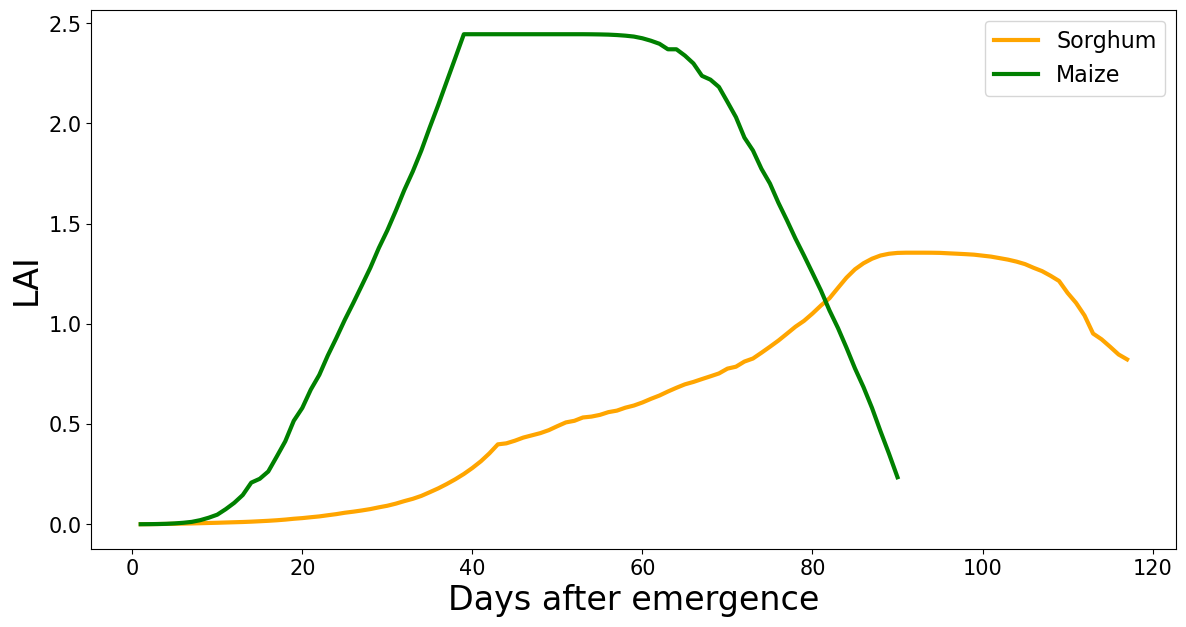

In [35]:
fig = plt.figure(figsize=(14, 7))

labels = ["Sorghum", "Maize"]
colors = ["orange", "green"]
dyn = [daily_dynamics_sorghum, daily_dynamics_maize]

for daily_dynamics, color, label in zip(dyn, colors, labels):
    thermal_time = [value["Thermal time"] for value in daily_dynamics.values()]
    leaf_area_plant = [value["Plant leaf area"] for value in daily_dynamics.values()]
    sen_leaf_area_plant = [value["Plant senescent leaf area"] for value in daily_dynamics.values()]
    height_canopy = [value["Plant height"] for value in daily_dynamics.values()]
    dae = range(1,len(thermal_time)+1)
    plt.plot(dae, [(la-sen)*density/10000 for la,sen in zip(leaf_area_plant, sen_leaf_area_plant)], color=color, linewidth=3, label=label)
    # plt.plot(dae, [la*density/10000/2 for la,sen in zip(leaf_area_plant, sen_leaf_area_plant)], color=color, linewidth=3, label=label)

plt.xlabel("Days after emergence", fontsize=24)
plt.ylabel("LAI", fontsize=24)
plt.legend(fontsize=16)
plt.tick_params(labelsize=15)
plt.show()

In [36]:
def define_params(dynamics_file, plant_file, archi_params, end=-1):    
    # Retrieve STICS management and senescence parameters
    _, daily_dynamics, lifespan, lifespan_early, _ = get_stics_data(
        file_tec_xml=tec_file,  # Path to the STICS management XML file
        file_plt_xml=plant_file,  # Path to the STICS plant XML file
        stics_output_file=dynamics_file,  # Path to the STICS output file
        end=end
    )

    pot_factor_lai = 2.7
    pot_factor_height = 3

    # Complete ArchiCrop parameters with values from constraint
    archi_params = constrain_archi_params(archi_params=archi_params, daily_dynamics=daily_dynamics, 
                                            lifespan=lifespan, lifespan_early=lifespan_early, 
                                            pot_factor_lai=pot_factor_lai, pot_factor_height=pot_factor_height)
    
    # Generate samples for ArchiCrop parameters 
    param_sets = param_sampling(archi_params=archi_params, n_samples=1)

    # Compute viable parameters wrt the dynamic constraint of LAI and height
    param_sets = compute_viable_params(
        params_sets=param_sets, 
        daily_dynamics=daily_dynamics, 
        pot_factor_lai=pot_factor_lai, pot_factor_height=pot_factor_height)
    
    return param_sets

In [37]:
params_sorghum = define_params(sorghum_stics_output_file, sorghum_plant_file, archi_sorghum, end=end)
sorghum = ArchiCrop(daily_dynamics=daily_dynamics_sorghum, **params_sorghum[1], plant_orientation=90)
sorghum.generate_potential_plant()
growing_sorghum = sorghum.grow_plant()

params_maize = define_params(maize_stics_output_file, maize_plant_file, archi_maize, end=end)
maize = ArchiCrop(daily_dynamics=daily_dynamics_maize, **params_maize[1], plant_orientation=90)
maize.generate_potential_plant()
growing_maize = maize.grow_plant()

[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
[0.96428571 0.96825397 0.97222222 0.97619048 0.98015873 0.98412698
 0.98809524 0.99206349 0.99603175 1.        ]


In [38]:
# Rows
conv_coef = 100 # Convert from m to cm
inter_row = 0.7
coord_maize_1 = (0,0,0)
coord_maize_2 = (0,inter_row * conv_coef,0) 
coord_sorghum_1 = (0,inter_row * conv_coef * 2,0) 
coord_sorghum_2 = (0,inter_row * conv_coef * 3,0) 
positions = [coord_maize_1] + [coord_maize_2] + [coord_sorghum_1] + [coord_sorghum_2]
inter_plant = 1.0 / inter_row / density
print(inter_plant)
domain = ((0, -0.5 * inter_plant * conv_coef), (4 * inter_row * conv_coef, 0.5 * inter_plant * conv_coef))
lights=[(1,(0,0,-1))]
dates = [value["Date"] for value in daily_dynamics_sorghum.values()]

0.2380952380952381


In [57]:
green = Color3((0,50,0))
day = 65

width = 3
length = 1.3
domain_crop = ((0, 0), (width * conv_coef, length * conv_coef))
nrow = max(1, int(round(float(width) / inter_row))) 
plant_per_row = max(1, int(round(float(length) / inter_plant)))

dx = inter_plant * conv_coef
dy = inter_row * conv_coef
positions_crop, domain = regular(
    nrow * plant_per_row, int(nrow), dx, dy, int(plant_per_row)
)
domain_area = (
    abs(domain_crop[1][0] - domain_crop[0][0]) / conv_coef
    * abs(domain_crop[1][1] - domain_crop[0][1]) / conv_coef
)

# sorting by ranks
positions_crop = sorted(positions_crop, key=itemgetter(1, 0))
# print(positions_crop)

list_of_graphs = [growing_sorghum[day]]*int(plant_per_row)*2 + [growing_maize[day]]*int(plant_per_row)*2

df_weather = stics_weather_3d(filename=weather_file, daily_dynamics=daily_dynamics)

# Define incident PAR
incident_rads = list(df_weather.itertuples())
incident_rad = incident_rads[day-1]
par = incident_rad.rad * 0.48 * 0.95

irr = sky_irradiance(daydate=incident_rad.daydate, day_ghi=par, **location)
sun, sky = sky_sources(sky_type='clear_sky', sky_irradiance=irr, scale='global') #, source_irradiance='horizontal')
lights = caribu_light_sources(sun, sky)
# lights = [(light[0]*domain_area, light[1]) for light in lights]
# lights=[(1,(0,0,-1))]

# scene, labels = build_scene(growing_sorghum[day], leaf_material=Material(green), stem_material=Material(green), senescence=True)
scene, labels = build_scene(list_of_graphs, positions_crop, leaf_material=Material(green), stem_material=Material(green), senescence=True)
cs, raw, agg = illuminate(scene, light=lights, labels=labels, domain=domain_crop, direct=False)
sc, v=cs.plot(raw, display=False)
v99 = np.percentile(v, 99)
nvalues=np.array(v)
nvalues[nvalues>v99]=v99
v = nvalues.tolist()
PlantGL(sc, group_by_color=False, property=v)

Plot(antialias=3, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], background…

In [22]:
green=Color3((0,50,0))
day = 60
list_of_graphs = [growing_maize[day]] + [growing_maize[day]] + [growing_sorghum[day]] + [growing_sorghum[day]] 
# scene, labels = build_scene(growing_sorghum[day], leaf_material=Material(green), stem_material=Material(green), senescence=True)
scene, labels = build_scene(list_of_graphs, positions, leaf_material=Material(green), stem_material=Material(green), senescence=True)
Viewer.display(scene)

In [23]:
def simulation_cycle(dates, daily_dynamics, growing_plant1, growing_plant2, positions, domain, lights):

    green=Color3((0,50,0))

    results_cycle = {
            'scene': [],
            'cs': [],
            'raw': [],
            'agg': []
    }

    # Read weather data
    df_weather = stics_weather_3d(filename=weather_file, daily_dynamics=daily_dynamics)

    # Define incident PAR
    incident_rads = list(df_weather.itertuples())
    
    for day in range(1,len(dates)+1):
    # for day in range(80,85):
        list_of_graphs = []
        growing_plants = [growing_plant1, growing_plant2]
        for gp in growing_plants:
            if day not in gp:
                list_of_graphs.append(gp[max(gp)])
            else:
                list_of_graphs.append(gp[day])
        # list_of_graphs = [growing_plant1[day]] + [growing_plant2[day]] 

        incident_rad = incident_rads[day-1]
        par = incident_rad.rad * 0.48 * 0.95

        irr = sky_irradiance(daydate=incident_rad.daydate, day_ghi=par, **location)
        sun, sky = sky_sources(sky_type='clear_sky', sky_irradiance=irr, scale='global') #, source_irradiance='horizontal')
        lights = caribu_light_sources(sun, sky)
    
        scene, labels = build_scene(list_of_graphs, positions, leaf_material=Material(green), stem_material=Material(green), senescence=True)
        cs, raw, agg = illuminate(scene, light=lights, labels=labels, domain=domain, direct=False)
        agg = mean_leaf_irradiance(agg)

        results_cycle['scene'].append(scene)
        results_cycle['cs'].append(cs)
        results_cycle['raw'].append(raw)
        results_cycle['agg'].append(agg)

    return results_cycle


In [24]:
df_weather = stics_weather_3d(filename=weather_file, daily_dynamics=daily_dynamics_sorghum)

# Define incident PAR
incident_rads = list(df_weather.itertuples())
len(incident_rads)

# for day in range(1,len(dates)+1):
#     par = incident_rads[day-1].rad * 0.48 * 0.95
#     print(par)

117

In [25]:
len(growing_sorghum)

117

In [26]:
len(growing_maize)

90

In [27]:
results_cycle = simulation_cycle(dates, daily_dynamics_sorghum, growing_sorghum, growing_maize, positions, domain, lights)

In [28]:
d = 65
sc, v=results_cycle['cs'][d].plot(results_cycle['raw'][d])

In [29]:
# energy_maize = [results_cycle['agg'][t].loc[0, 'Energy']*density/2 for t in range(5)]
# plt.plot(range(5), energy_maize, color='green')
# energy_sorghum = [results_cycle['agg'][t].loc[1, 'Energy']*density/2 for t in range(5)]
# plt.plot(range(5), energy_sorghum, color='orange')
# plt.plot(range(5), np.array(energy_sorghum) + np.array(energy_maize), color='black')
# plt.show()

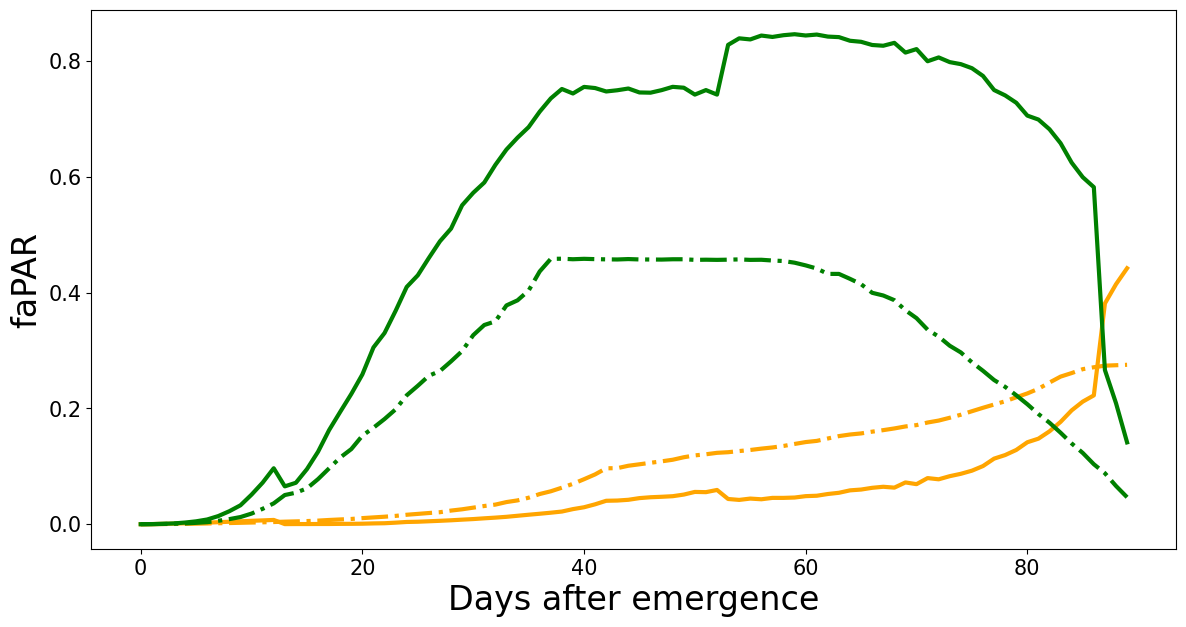

In [30]:
fig = plt.figure(figsize=(14, 7))

stop = 90

sum_fapar = [0]*len(daily_dynamics_sorghum)
for i, (daily_dynamics, color) in enumerate(zip(dyn, colors)):
    par_inc_stics = [value["Incident PAR"] for value in daily_dynamics.values()][:stop]
    # par_caribu = [results_cycle['agg'][t].loc[i, 'Energy']*density/2/pinc for t,pinc in enumerate(par_inc_stics)]
    par_caribu = [results_cycle['agg'][t].loc[i, 'Energy']/(inter_plant*4*inter_row)/pinc for t,pinc in enumerate(par_inc_stics)]
    plt.plot(range(len(par_caribu)), par_caribu, color=color, linewidth=3, linestyle='-.')
    par_abs_stics = [value["Absorbed PAR"] for value in daily_dynamics.values()][:stop]
    for j,p in enumerate(par_caribu):
        sum_fapar[j] += p
    plt.plot(range(len(par_abs_stics)), par_abs_stics, color=color, linewidth=3)

# plt.plot(sum_fapar, color="black")
plt.xlabel("Days after emergence", fontsize=24)
plt.ylabel("faPAR", fontsize=24)
# plt.legend(fontsize=16)
plt.tick_params(labelsize=15)

today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"../figures/", exist_ok=True)  
plt.savefig(f"../figures/abstract_FSPM_fig_1B_row.png", dpi=1000)

plt.show()

In [31]:
results_cycle['agg'][60:90]

[         Energy      area  Irradiance
 plant                                
 0      0.824095  0.124345    6.627506
 1      2.596307  0.430037    6.037405
 2      0.445514  0.074025    6.018441
 3      2.183200  0.360821    6.050646,
          Energy      area  Irradiance
 plant                                
 0      1.006546  0.127918    7.868653
 1      3.088297  0.425884    7.251495
 2      0.524224  0.072686    7.212175
 3      2.622803  0.359861    7.288382,
          Energy      area  Irradiance
 plant                                
 0      0.900579  0.132046    6.820212
 1      2.629278  0.418512    6.282447
 2      0.436534  0.069806    6.253498
 3      2.270129  0.358948    6.324399,
          Energy      area  Irradiance
 plant                                
 0      0.842279  0.135486    6.216711
 1      2.392501  0.418512    5.716689
 2      0.397110  0.069806    5.688730
 3      2.065757  0.358948    5.755036,
          Energy      area  Irradiance
 plant               